## Task 2

Text(0.5, 0.98, 'B_1')

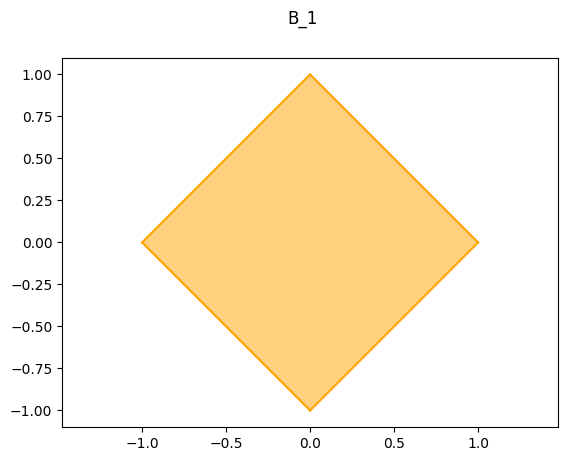

In [4]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# B_1
x_values_1 = np.linspace(0,1,100)
x_values_2 = np.linspace(-1,0,100)

def f_1(x):
    return 1-x

def f_2(x):
    return x + 1

def f_3(x):
    return -1 -x

def f_4(x):
    return -1 + x

y_values_1 = [f_1(x) for x in x_values_1]
y_values_2 = [f_2(x) for x in x_values_2]
y_values_3 = [f_3(x) for x in x_values_2]
y_values_4 = [f_4(x) for x in x_values_1]

points = list(zip(
    x_values_1, y_values_1
)) + list(zip(x_values_2[::-1], y_values_3[::-1]))

fig, ax = plt.subplots()
diamond = Polygon(points, closed=True, color='orange',alpha=0.5)
ax.add_patch(diamond)

plt.plot(x_values_1, y_values_1, color = 'orange')
plt.plot(x_values_2, y_values_2, color = 'orange')
plt.plot(x_values_2, y_values_3, color = 'orange')
plt.plot(x_values_1, y_values_4,color = 'orange')

plt.axis("equal")
plt.suptitle('B_1')

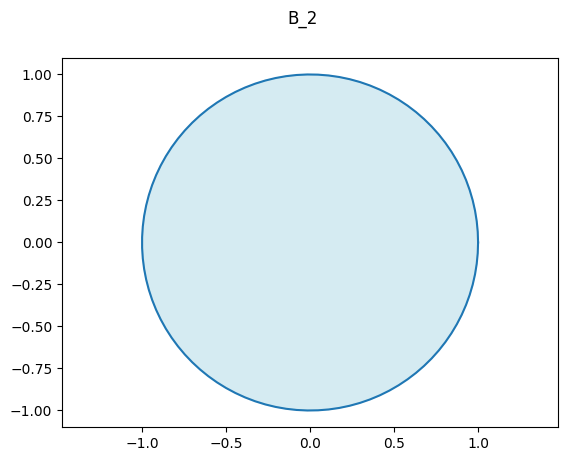

In [ ]:
# B_2
tetha_value_c = np.linspace(0,2*np.pi,100)
cos_values = np.cos(tetha_value_c) 
sin_values = np.sin(tetha_value_c) 
plt.axis("equal")
plt.suptitle('B_2')

plt.plot(cos_values,sin_values)
plt.fill(cos_values, sin_values, color="lightblue", alpha=0.5)

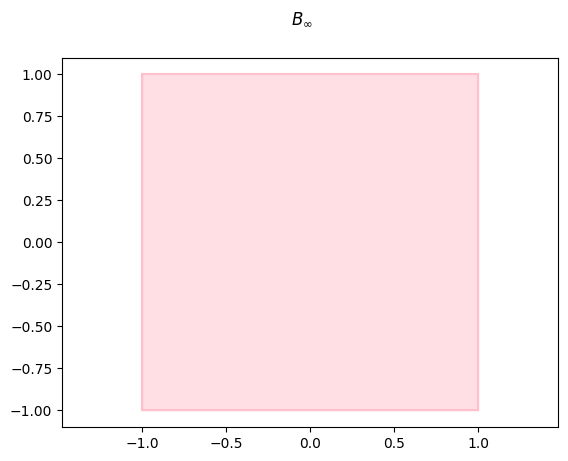

In [3]:
# B_infty
x_values = np.linspace(-1,1,100)
y_values = np.ones(100)
plt.axis("equal")
plt.suptitle(r'$B_{\infty}$')

x_polygon = np.concatenate([x_values, y_values[::-1], -x_values, -y_values[::-1]])
y_polygon = np.concatenate([y_values, x_values[::-1], -y_values, -x_values])

plt.fill(x_polygon, y_polygon, color='pink', alpha=0.5)

plt.plot(x_values,y_values, color = 'pink')
plt.plot(x_values,-1* y_values, color = 'pink')
plt.plot(y_values, x_values,color = 'pink')
plt.plot(-1* y_values, x_values, color = 'pink')

## Task 13-14

In [ ]:
# Import libraries
import numpy as np

tolerance = 1e-6
max_iterations = 1000

# -------------------------------------------------------------
# The following functions (weiszfeld and geometric_median_gradient) 
# are two different algorithms for solving the weighted geometric median problem
#
#      min_x sum_i v_i * d2(a_i , x)
#
# where:
#   a_i = given locations
#   v_i = weights
#   d2  = Euclidean distance
#
# Inputs:
# points  -> list of locations a_i for i = 1, 2, ...
# weights -> list of corresponding weights v_i
# x0      -> optional starting point
# tol     -> tolerance used for stopping, choosen as epsilon = 10^(-6)
# max_iter-> maximum number of iterations
#
# Output:
# x       -> approximate geometric median
# -------------------------------------------------------------

# -------------------------------------------------------------
# WEISZFELD ALGORITHM IMPLEMENTATION
# -------------------------------------------------------------

def weiszfeld(points, weights, x0=None, tol=tolerance, max_iter=max_iterations):

    # Convert the lists (of points and weights) into a numpy arrays
    points = np.array(points)
    weights = np.array(weights)

    # ---------------------------------------------------------
    # Step (a): Check if the solution is one of the data points
    # ---------------------------------------------------------

    for k in range(len(points)):

        diff = points[k] - points
        dist = np.linalg.norm(diff, axis=1) 

        mask = dist > 0 # remove i = k to avoid division by zero

        test = np.sum(weights[mask,None] * diff[mask] / dist[mask,None], axis=0)

        if np.linalg.norm(test) <= weights[k]:
            return points[k], 0, points[k]
        
    # ---------------------------------------------------------
    # Step (b): Choose a starting point x = (x_1, x:2) by solving the median problem using the squared Euclidean norm
    # ---------------------------------------------------------

    if x0 is None:
        # formular from task 7
        x0 = np.sum(weights[:, None] * points, axis=0) / np.sum(weights)
    else:
        # If a starting point it provided, use it
        x0 = np.array(x0)

    x = x0

    # ---------------------------------------------------------
    # Iteration loop
    # ---------------------------------------------------------
    for iteration in range(max_iter):
        # -----------------------------------------------------
        # Step (c): Calculate x_new with WEISZFELD UPDATE FORMULA
        #
        # x_new =
        #   ( sum_i (v_i * a_i / d(a_i,x)) )
        #   -------------------------------
        #        sum_i (v_i / d(a_i,x))
        # -----------------------------------------------------

        # Compute Euclidean distances from current point x to every a_i (in points)
        distances = np.linalg.norm(points - x, axis=1) 

        # If x is extremely close to one of the data points, the formula would divide by zero. 
        # To avoid this, return the appropriate data point as the solution.
        # OBS! It may not be the solution to the geometric median problem but it is a safe stopping rule.
        if np.any(distances < tol):
            return points[np.argmin(distances)], iteration+1, x0

        # Compute numerator of the formula
        numerator = np.sum((weights[:, None] * points) / distances[:, None], axis=0)

        # Compute denominator
        denominator = np.sum(weights / distances)

        # Compute the new point x^(new)
        x_new = numerator / denominator

        # -----------------------------------------------------
        # Step (d): Check is x_new satisfies the TERMINATION CRITERION FROM TASK 12
        # -----------------------------------------------------
        # The algorithm can stop when
        #
        #   UB(x) / LB(x) < epsilon
        #
        # where
        #
        # UB(x) = ||gradient(f(x))|| * sigma(x)
        # LB(x) = f(x) - ||gradient(f(x))|| * sigma(x)
        #
        # Here we compute all components needed for this test.
        # -----------------------------------------------------

        # Compute the objective (geometric median) function value
        # f(x) = sum_i v_i * d(a_i , x)
        f_x = np.sum(weights * distances)

        # Compute gradient of f(x)
        # gradient(f(x)) = sum_i v_i (x - a_i)/d2(a_i , x), for x =/= a_i
        grad = np.sum(weights[:, None] * (x - points) / distances[:, None], axis=0)

        # Compute gradient norm ||gradient(f(x))||
        grad_norm = np.linalg.norm(grad)

        # sigma(x) = max distance from x to the convex hull of the points.
        # The maximum distance to a convex hull is always attained at one of its vertices a_i,
        # so it is sufficient to compute the maximum distance to the given data points.
        sigma = np.max(distances)

        # Upper bound of improvement
        UB = grad_norm * sigma

        # Lower bound for optimal value
        LB = f_x - UB

        # Avoid division by zero
        if LB > 0:

            # Compute ratio UB/LB
            ratio = UB / LB

            # -------------------------------------------------
            # STOP IF TERMINATION CRITERION IS MET
            # -------------------------------------------------
            if ratio < tol:
                return x_new, iteration+1, x0

        # Secondary stopping rule for numerical stability (if the point barely moves anymore we stop)
        if np.linalg.norm(x_new - x) < tol:
            return x_new, iteration+1, x0

        # Update iteration point and go to Step (c).
        x = x_new

    # If maximum iterations reached, return current estimate
    return x, iteration+1, x0


# -------------------------------------------------------------
# GRADIENT DESCENT METHOD WITH BACKTRACKING
# -------------------------------------------------------------
def geometric_median_gradient(points, weights, x0=None, tol=tolerance, max_iter=max_iterations):
    
    # Convert the lists (of points and weights) into a numpy arrays
    points = np.array(points)
    weights = np.array(weights)

    # ---------------------------------------------------------
    # Step (a): Check if the solution is one of the data points
    # ---------------------------------------------------------
    for k in range(len(points)):

        diff = points[k] - points
        dist = np.linalg.norm(diff, axis=1) 

        mask = dist > 0 # remove i = k to avoid division by zero

        test = np.sum(weights[mask,None] * diff[mask] / dist[mask,None], axis=0)

        if np.linalg.norm(test) <= weights[k]:
            return points[k], 0, points[k]
        
    # ---------------------------------------------------------
    # Step (b): Choose a starting point x = (x_1, x:2) by solving the median problem using the squared Euclidean norm
    # ---------------------------------------------------------
    if x0 is None:
        # formular from task 7
        x0 = np.sum(weights[:, None] * points, axis=0) / np.sum(weights)
    else:
        # If a starting point it provided, use it
        x0 = np.array(x0)

    x = x0

    # ---------------------------------------------------------
    # Step (c-d): GRADIENT DESCENT METHOD WITH BACKTRACKING
    # ---------------------------------------------------------
    for iteration in range(max_iter):

        # Distances ||x-a_i||
        distances = np.linalg.norm(x - points, axis=1)
        distances = np.maximum(distances, tol) # Avoid division by zero

        # Gradient of the objective function
        grad = np.sum(weights[:,None] * (x - points) / distances[:,None], axis=0)

        # Initial step size
        step = 1

        # Backtracking reduction factor
        beta = 0.5

        # Compute f_old (current objective value)
        f_old = np.sum(weights * distances)
        
        # Backtracking loop to find good step size
        while True:

            # Gradient descent update
            x_new = x - step * grad

            # Compute objective values at candidate point
            f_new = np.sum(weights * np.linalg.norm(points - x_new, axis=1))

            # If function decreases, accept step
            if f_new < f_old:
                break
            # Prevent infinite loop 
            if step < tol:
                break

            # Otherwise reduce step size
            step *= beta

        # Stop if update becomes very small
        if np.linalg.norm(x_new - x) < tol:
            return x_new, iteration+1, x0

        x = x_new

    return x, iteration+1, x0

In [22]:
# -------------------------------------------------------------
# (i): Unit Square
# -------------------------------------------------------------

points_unit = [

    [-1, -1],
    [-1, 1],
    [1, -1],
    [1, 1]
]

weights_unit = [1,1,1,1]

# -------------------------------------------------------------
# (ii): Original Test Cases
# -------------------------------------------------------------

# -------------------------------------------------------------
# Custom Case 1 - weighted triangle
# -------------------------------------------------------------

points_triangle = [
    [0,0],
    [5,0],
    [10,0],
    [7.5, 4],
    [5,8],
    [2.5,4]
]

weights_triangle = [1,1,1,5,5,5]

# -------------------------------------------------------------
# Custom Case 2 - heavy weights
# -------------------------------------------------------------

points_heavy = [
    [0,0],
    [5,0],
    [10,0],
    [7.5, 4],
    [5,8],
    [2.5,4]
]

weights_heavy = [1,1,15,15,1,15]

# -------------------------------------------------------------
# Custom Case 3 - on a line
# -------------------------------------------------------------

points_line = [
    [-4,0],
    [-2,0],
    [0,0],
    [0.5,0],
    [0.7,0],
    [1,0],
    [6,0]
]

weights_line = [1,5,5,6,1,1,1]

# -------------------------------------------------------------
# Custom Case 4 - random
# -------------------------------------------------------------

np.random.seed(1)

points_random = np.random.randn(20,2)
weights_random = np.ones(20)

# -------------------------------------------------------------
# Custom Case 5 - two distinct clusters w/ different weights
# -------------------------------------------------------------
points_clusters = [
    # Left cluster (lighter)
    [-5, 0], [-4, 1], [-5, 1], [-4, 0],
    # Right cluster (heavier)
    [5, 0], [6, 1], [5, 1], [6, 0], [5.5, 0.5]
]

weights_clusters = [1, 1, 1, 1,  # left cluster weight 
                    1, 2, 3, 3, 1]  # right cluster 

In [23]:
# Import libraries
import matplotlib.pyplot as plt
import time

def run_and_plot_weiszfeld(points, weights, plottitle):
    start = time.time()
    result, iteration, x0 = weiszfeld(points, weights)
    end = time.time()
    runtime = end - start

    print(f"\nWeiszfeld Algorithm - {plottitle}")
    print(f"  Minimizer: {result}")
    print(f"  Iterations: {iteration}")
    print(f"  Runtime: {runtime:.4f} s")
    print(f"  Tolerance: {tolerance}")

    points = np.array(points)
    plt.scatter(points[:,0], points[:,1], label="Data points")
    plt.scatter(x0[0], x0[1], marker="o", label="Starting point")
    plt.scatter(result[0], result[1], marker="x", s=200, label="Minimizer")
    plt.legend()
    plt.title(f"Weiszfeld Algorithm: {plottitle}")
    plt.axis('equal')
    plt.show()

    return result, iteration, runtime

def run_and_plot_gradient_descent(points, weights, plottitle):
    start = time.time()
    result, iteration, x0 = geometric_median_gradient(points, weights)
    end = time.time()
    runtime = end - start

    print(f"\nGradient Descent - {plottitle}")
    print(f"  Minimizer: {result}")
    print(f"  Iterations: {iteration}")
    print(f"  Runtime: {runtime:.4f} s")
    print(f"  Tolerance: {tolerance}")

    points = np.array(points)
    plt.scatter(points[:,0], points[:,1], label="Data points")
    plt.scatter(x0[0], x0[1], marker="o", label="Starting point")
    plt.scatter(result[0], result[1], marker="x", s=200, label="Minimizer")
    plt.legend()
    plt.title(f"Gradient Descent: {plottitle}")
    plt.axis('equal')
    plt.show()

    return result, iteration, runtime


Weiszfeld Algorithm - unit square
  Minimizer: [0. 0.]
  Iterations: 1
  Runtime: 0.0004 s
  Tolerance: 1e-06


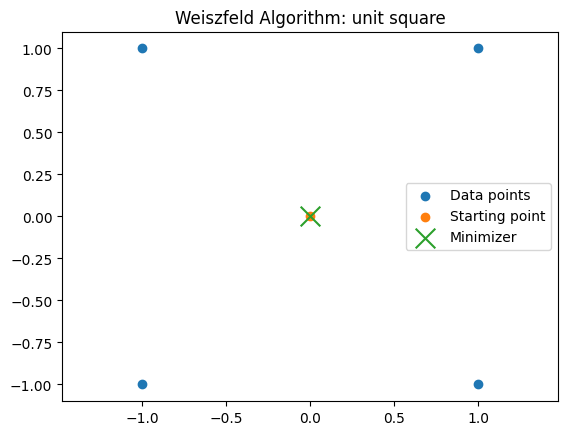


Weiszfeld Algorithm - weighted triangle
  Minimizer: [5.         4.68230532]
  Iterations: 13
  Runtime: 0.0005 s
  Tolerance: 1e-06


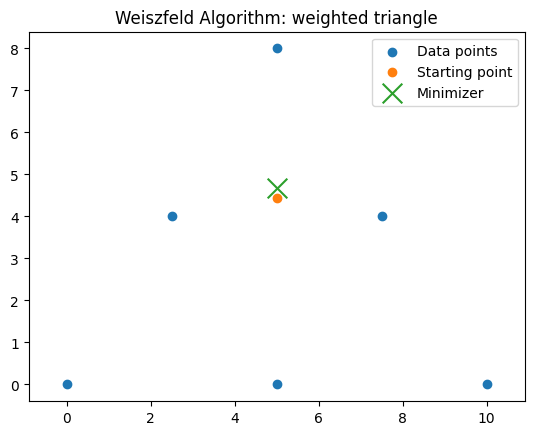


Weiszfeld Algorithm - heavy weights
  Minimizer: [7.39190816 3.84235305]
  Iterations: 149
  Runtime: 0.0035 s
  Tolerance: 1e-06


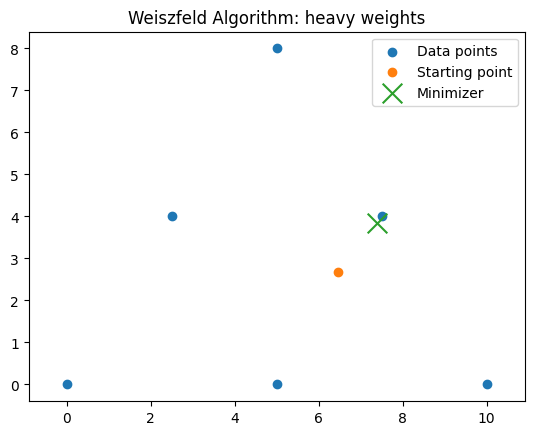


Weiszfeld Algorithm - on a line
  Minimizer: [0. 0.]
  Iterations: 0
  Runtime: 0.0001 s
  Tolerance: 1e-06


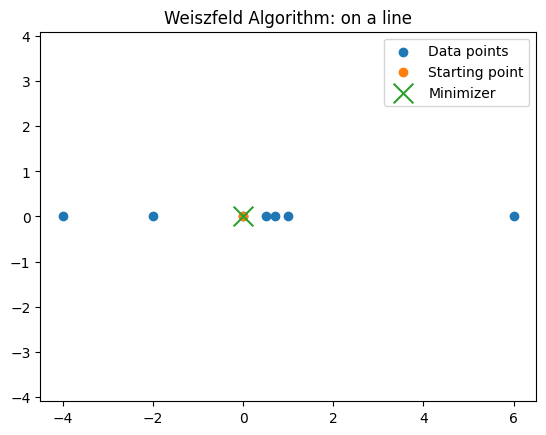


Weiszfeld Algorithm - random
  Minimizer: [ 0.07117829 -0.43217638]
  Iterations: 24
  Runtime: 0.0009 s
  Tolerance: 1e-06


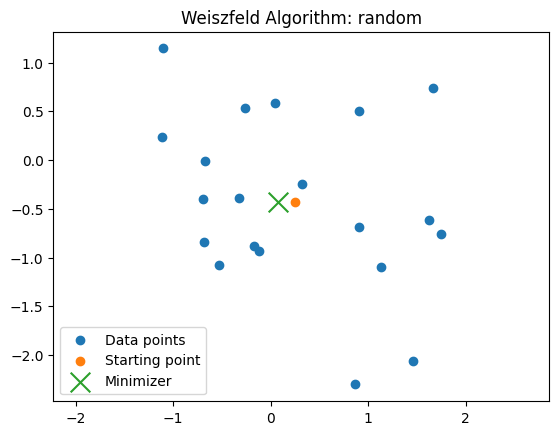


Weiszfeld Algorithm - two clusters
  Minimizer: [5.10011473 0.71717103]
  Iterations: 38
  Runtime: 0.0011 s
  Tolerance: 1e-06


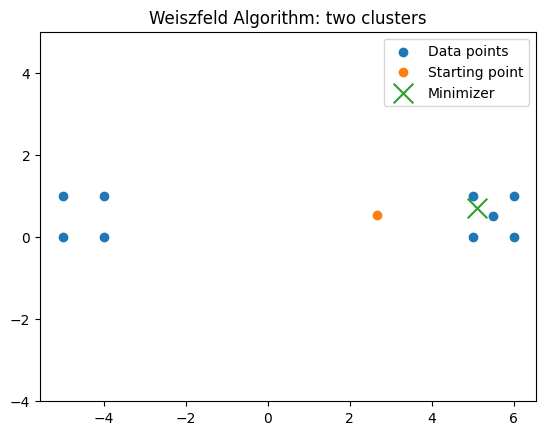


Gradient Descent - unit square
  Minimizer: [0. 0.]
  Iterations: 1
  Runtime: 0.0003 s
  Tolerance: 1e-06


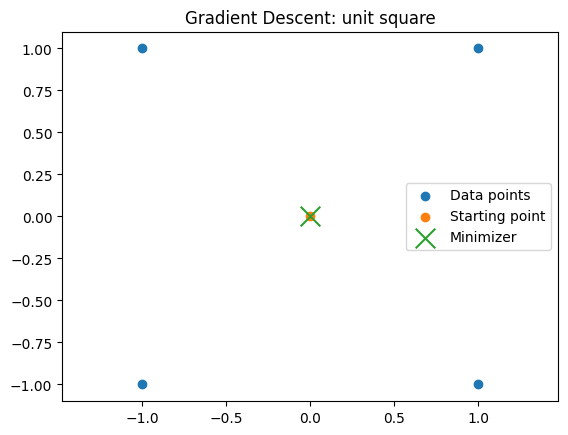


Gradient Descent - weighted triangle
  Minimizer: [5.         4.68230531]
  Iterations: 98
  Runtime: 0.0027 s
  Tolerance: 1e-06


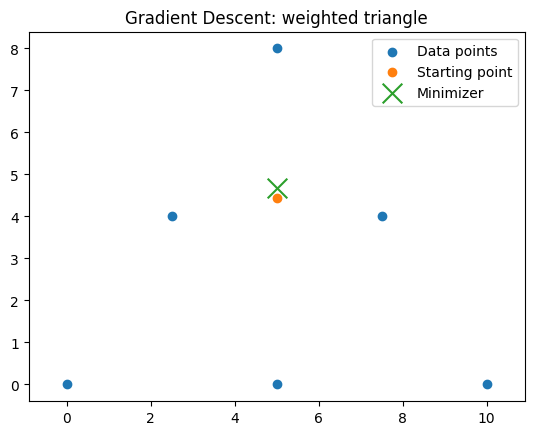


Gradient Descent - heavy weights
  Minimizer: [7.39191473 3.84236313]
  Iterations: 61
  Runtime: 0.0033 s
  Tolerance: 1e-06


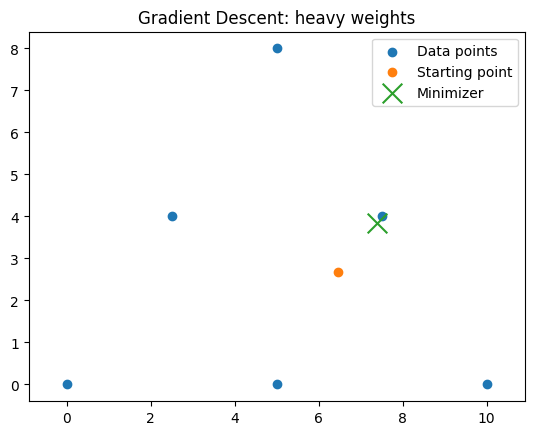


Gradient Descent - on a line
  Minimizer: [0. 0.]
  Iterations: 0
  Runtime: 0.0001 s
  Tolerance: 1e-06


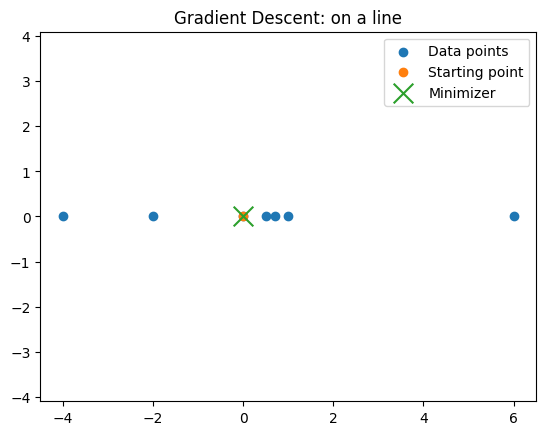


Gradient Descent - random
  Minimizer: [ 0.07117682 -0.43217646]
  Iterations: 45
  Runtime: 0.0021 s
  Tolerance: 1e-06


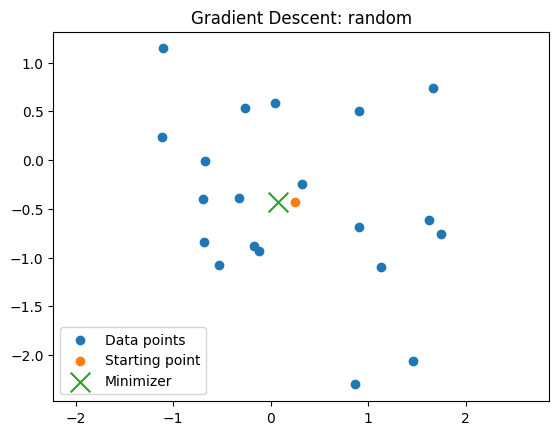


Gradient Descent - two clusters
  Minimizer: [5.10011365 0.71717364]
  Iterations: 61
  Runtime: 0.0024 s
  Tolerance: 1e-06


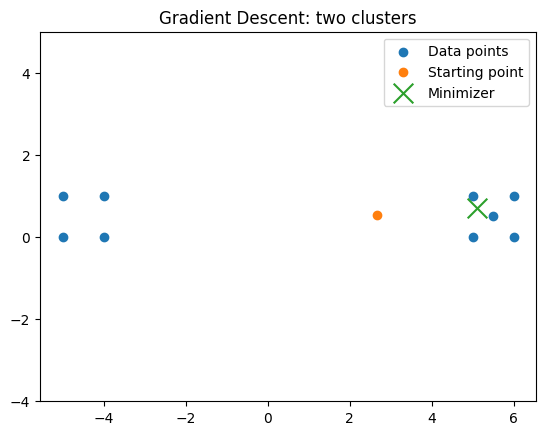

In [24]:
weiszfeld_unit = run_and_plot_weiszfeld(points = points_unit, weights=weights_unit, plottitle = "unit square")
weiszfeld_triangle = run_and_plot_weiszfeld(points = points_triangle, weights=weights_triangle, plottitle = "weighted triangle")
weiszfeld_heavy = run_and_plot_weiszfeld(points = points_heavy, weights=weights_heavy, plottitle = "heavy weights")
weiszfeld_line = run_and_plot_weiszfeld(points = points_line, weights=weights_line, plottitle = "on a line")
weiszfeld_random = run_and_plot_weiszfeld(points = points_random, weights=weights_random, plottitle = "random")
weiszfeld_clusters = run_and_plot_weiszfeld(points = points_clusters, weights=weights_clusters, plottitle = "two clusters")

gradient_descent_unit = run_and_plot_gradient_descent(points = points_unit, weights=weights_unit, plottitle = "unit square")
gradient_descent_triangle = run_and_plot_gradient_descent(points = points_triangle, weights=weights_triangle, plottitle = "weighted triangle")
gradient_descent_heavy = run_and_plot_gradient_descent(points = points_heavy, weights=weights_heavy, plottitle = "heavy weights")
gradient_descent_line = run_and_plot_gradient_descent(points = points_line, weights=weights_line, plottitle = "on a line")
gradient_descent_random = run_and_plot_gradient_descent(points = points_random, weights=weights_random, plottitle = "random")
gradient_descent_clusters = run_and_plot_gradient_descent(points = points_clusters, weights=weights_clusters, plottitle = "two clusters")


In [25]:
datasets = [
    ("Unit square", weiszfeld_unit, gradient_descent_unit),
    ("Triangle", weiszfeld_triangle, gradient_descent_triangle),
    ("Heavy weights", weiszfeld_heavy, gradient_descent_heavy),
    ("On a line", weiszfeld_line, gradient_descent_line),
    ("Random", weiszfeld_random, gradient_descent_random),
    ("Clusters", weiszfeld_clusters, gradient_descent_clusters)
    ]
print("--------------------------------------------------------------------------------")
print("Minimizers Comparison")
print("--------------------------------------------------------------------------------")
print(f"{'Dataset':<15} {'Weiszfeld':<25} {'Gradient':<25} {'Difference':<15}")
print("--------------------------------------------------------------------------------")

for name, weiszfeld_result, gradient_result in datasets:
    # Extract points
    weiszfeld_point = weiszfeld_result[0]
    gradient_point = gradient_result[0]
    
    # Calculate difference
    diff = np.linalg.norm(weiszfeld_point - gradient_point)
    
    # Format points nicely
    w_point_str = f"({weiszfeld_point[0]:.6f}, {weiszfeld_point[1]:.6f})"
    g_point_str = f"({gradient_point[0]:.6f}, {gradient_point[1]:.6f})"
    
    
    print(f"{name:<15} {w_point_str:<25} {g_point_str:<25} {diff:<15.2e}")
print("--------------------------------------------------------------------------------")
print("Tolerance used:", tolerance)

--------------------------------------------------------------------------------
Minimizers Comparison
--------------------------------------------------------------------------------
Dataset         Weiszfeld                 Gradient                  Difference     
--------------------------------------------------------------------------------
Unit square     (0.000000, 0.000000)      (0.000000, 0.000000)      0.00e+00       
Triangle        (5.000000, 4.682305)      (5.000000, 4.682305)      1.70e-08       
Heavy weights   (7.391908, 3.842353)      (7.391915, 3.842363)      1.20e-05       
On a line       (0.000000, 0.000000)      (0.000000, 0.000000)      0.00e+00       
Random          (0.071178, -0.432176)     (0.071177, -0.432176)     1.47e-06       
Clusters        (5.100115, 0.717171)      (5.100114, 0.717174)      2.83e-06       
--------------------------------------------------------------------------------
Tolerance used: 1e-06


In [ ]:
results = []
results.append([
    "Unit square",
    weiszfeld_unit[0],
    weiszfeld_unit[1],
    weiszfeld_unit[2]
])
results.append([
    "Weighted tri.",
    weiszfeld_triangle[0],
    weiszfeld_triangle[1],
    weiszfeld_triangle[2]
])
results.append([
    "Heavy weights",
    weiszfeld_heavy[0],
    weiszfeld_heavy[1],
    weiszfeld_heavy[2]
])
results.append([
    "on a line",
    weiszfeld_line[0],
    weiszfeld_line[1],
    weiszfeld_line[2]
])
results.append([
    "Random",
    weiszfeld_random[0],
    weiszfeld_random[1],
    weiszfeld_random[2]
])
results.append([
    "Clusters",
    weiszfeld_clusters[0],
    weiszfeld_clusters[1],
    weiszfeld_clusters[2]
])
print("-------------------------------------------------------")
print("Weiszfeld Results")
print("---------------------------------------------")
print(f"{'Dataset':<15}{'Minimizer':<20}{'Iterations':<12}{'Runtime (s)'}")

for r in results:
    x, y = r[1]
    point_str = f"({x:.1f}, {y:.1f})"
    print(f"{r[0]:<15}{point_str:<20}{r[2]:<12}{r[3]:.4f}")

print("---------------------------------------------")
print("Tolerance used:", tolerance)

-------------------------------------------------------
Weiszfeld Results
---------------------------------------------
Dataset        Minimizer           Iterations  Runtime (s)
Unit square    (0.0, 0.0)          1           0.0004
Weighted tri.  (5.0, 4.7)          13          0.0005
Heavy weights  (7.4, 3.8)          149         0.0035
on a line      (0.0, 0.0)          0           0.0001
Random         (0.1, -0.4)         24          0.0009
Clusters       (5.1, 0.7)          38          0.0011
---------------------------------------------
Tolerance used: 1e-06


In [27]:
results = []
results.append([
    "Unit square",
    "Weiszfeld",
    weiszfeld_unit[1],
    weiszfeld_unit[2]
])
results.append([
    "Unit square",
    "Gradient descent",
    gradient_descent_unit[1],
    gradient_descent_unit[2]
])
results.append([
    "Weighted tri.",
    "Weiszfeld",
    weiszfeld_triangle[1],
    weiszfeld_triangle[2]
])
results.append([
    "Weighted tri.",
    "Gradient descent",
    gradient_descent_triangle[1],
    gradient_descent_triangle[2]
])
results.append([
    "Heavy weights",
    "Weiszfeld",
    weiszfeld_heavy[1],
    weiszfeld_heavy[2]
])
results.append([
    "Heavy weights",
    "Gradient descent",
    gradient_descent_heavy[1],
    gradient_descent_heavy[2]
])
results.append([
    "on a line",
    "Weiszfeld",
    weiszfeld_line[1],
    weiszfeld_line[2]
])
results.append([
    "on a line",
    "Gradient descent",
    gradient_descent_line[1],
    gradient_descent_line[2]
])
results.append([
    "Random",
    "Weiszfeld",
    weiszfeld_random[1],
    weiszfeld_random[2]
])
results.append([
    "Random",
    "Gradient descent",
    gradient_descent_random[1],
    gradient_descent_random[2]
])
results.append([
    "Clusters",
    "Weiszfeld",
    weiszfeld_clusters[1],
    weiszfeld_clusters[2]
])
results.append([
    "Clusters",
    "Gradient descent",
    gradient_descent_clusters[1],
    gradient_descent_clusters[2]
])
print("-------------------------------------------------------")
print("Comparison Table")
print("-------------------------------------------------------")
print(f"{'Dataset':<15}{'Algorithm':<20}{'Iterations':<12}{'Runtime (s)'}")

for r in results:
    print(f"{r[0]:<15}{r[1]:<20}{r[2]:<12}{r[3]:.4f}")
print("-------------------------------------------------------")

print("Tolerance used:", tolerance)

-------------------------------------------------------
Comparison Table
-------------------------------------------------------
Dataset        Algorithm           Iterations  Runtime (s)
Unit square    Weiszfeld           1           0.0004
Unit square    Gradient descent    1           0.0003
Weighted tri.  Weiszfeld           13          0.0005
Weighted tri.  Gradient descent    98          0.0027
Heavy weights  Weiszfeld           149         0.0035
Heavy weights  Gradient descent    61          0.0033
on a line      Weiszfeld           0           0.0001
on a line      Gradient descent    0           0.0001
Random         Weiszfeld           24          0.0009
Random         Gradient descent    45          0.0021
Clusters       Weiszfeld           38          0.0011
Clusters       Gradient descent    61          0.0024
-------------------------------------------------------
Tolerance used: 1e-06
